<a href="https://colab.research.google.com/github/naoya1110/ai_robotics_lab_2026_hands_on/blob/main/Week05_Convolutional_Neural_Network_and_CIFAR10_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network and CIFAR10 Dataset

## Introduction

In this notebook, we will learn about:

* Convolutional Neural Networks (CNNs)
* Conv2D Layer
* MaxPooling 2D Layer

Last week, we made a simple MLP model. It classified three iris types from four feature values, and it was made of linear layers only. We can also use such a model for images, but it does not work very well.

A **CNN** is much better for images. Before CNNs, image recognition was not very accurate. CNNs made it much better, and today they are even better than humans at some tasks. Almost all image recognition AI now uses CNNs.

Let's build a simple CNN and train it with the **CIFAR10** dataset. CIFAR10 has color images of 32x32 pixels in 10 groups, as shown below.

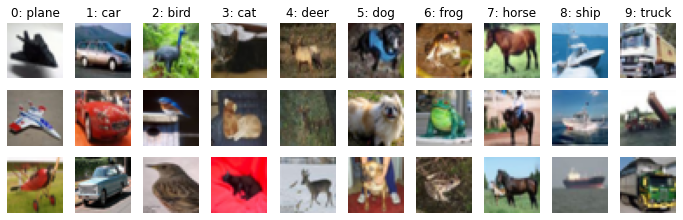

### GPU

Training a CNN needs many calculations, so we use a **GPU**. A GPU can do many calculations at the same time, so it is much faster than a CPU for this work. Please set your runtime type to GPU.

Let's check that we can use the GPU (cuda).

In [1]:
import torch

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(device)

cuda


### Import Packages

Let's import some common Python packages.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

## Data Preparation

### CIFAR10 Dataset

We can get the CIFAR10 dataset from `torchvision.datasets`. The `torchvision` package has many famous datasets, model architectures and image tools for computer vision.

*   CIFAR10 https://www.cs.toronto.edu/~kriz/cifar.html
* torchvison https://pytorch.org/vision/stable/index.html

In [3]:
from torchvision.datasets import CIFAR10

train_dataset = CIFAR10(root="cifar10", train=True, download=True)
test_dataset = CIFAR10(root="cifar10", train=False, download=True)

100%|██████████| 170M/170M [05:31<00:00, 514kB/s]


CIFAR10 has 50,000 images with labels for training, and 10,000 images for testing.

In [4]:
print("train dataset", len(train_dataset))
print("test dataset", len(test_dataset))

train dataset 50000
test dataset 10000


By using an index number, we can take out one image and its label. The image is in **PIL** format, so we can draw it with Matplotlib.

* PIL(Pillow) https://pillow.readthedocs.io/en/latest/handbook/index.html

type of image: <class 'PIL.Image.Image'>
size of image: (32, 32)
label: 6


Text(0.5, 1.0, '6')

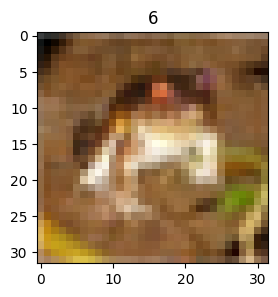

In [5]:
image, label = train_dataset[0]

print("type of image:", type(image))
print("size of image:", image.size)
print("label:", label)

plt.figure(figsize=(5,3))
plt.imshow(image)
plt.title(label)

The label is a number from 0 to 9, and each number means one group of images, as shown below.

In [6]:
classnames = {0:"plane",
              1:"car",
              2:"bird",
              3:"cat",
              4:"deer",
              5:"dog",
              6:"frog",
              7:"horse",
              8:"ship",
              9:"truck"}

classnames

{0: 'plane',
 1: 'car',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}

### torch.tensor

PyTorch works with tensors, so we have to change the images into the `torch.tensor` format. We can do it when we load the data: just add the parameter `transform=transforms.ToTensor()`.

In [7]:
from torchvision import transforms

train_dataset = CIFAR10(root="cifar10", train=True, download=False, transform=transforms.ToTensor())
test_dataset = CIFAR10(root="cifar10", train=False, download=False, transform=transforms.ToTensor())

Now the image data is a `torch.tensor`.

In [8]:
image, label = train_dataset[0]
print(type(image))

<class 'torch.Tensor'>


**Important:** A `PIL` image and a `torch.tensor` image keep the same numbers, but in a different order.

|  data format  |  shape  |
| :----: | :----: |
|  PIL  |  (32, 32, 3)  <br> (height, width, channel)|
|  torch.tensor  |  (3, 32, 32)  <br> (channel, height, width)|

"Channel" means the three colors: red, green and blue.

Matplotlib wants the PIL order, so it cannot draw an image with the shape (3, 32, 32). The next cell makes an error on purpose.


TypeError: Invalid shape (3, 32, 32) for image data

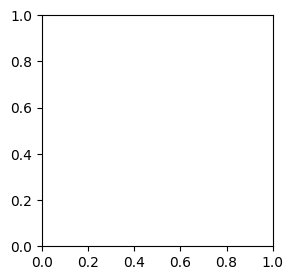

In [9]:
plt.figure(figsize=(5,3))
plt.imshow(image)    # this raises an error

### DataLoader

We make `DataLoader` objects to give the data to the model, just like we did with the Iris dataset. Here the batch size is 50, so the model gets 50 images at a time.

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=50, shuffle=False)

That's it for data preparation!

## Model Building

### Model Architecture

The next step is to build a Convolutional Neural Network (CNN).

Our model has three parts:

* **features**: `Conv2D` layers with `ReLU` activation functions, and `MaxPool2D` layers. This part finds the useful patterns (features) in the image, for example edges, colors and shapes.
* **junction**: an `AdaptiveAvgPool2d` layer and a `Flatten` layer. This part makes the size always the same, and then changes the 2D data into 1D data.
* **classifier**: `Linear` layers with a `ReLU` activation function. This part decides the group of the image from the features.

So the image goes through the model like this: find the features -> make them 1D -> classify.

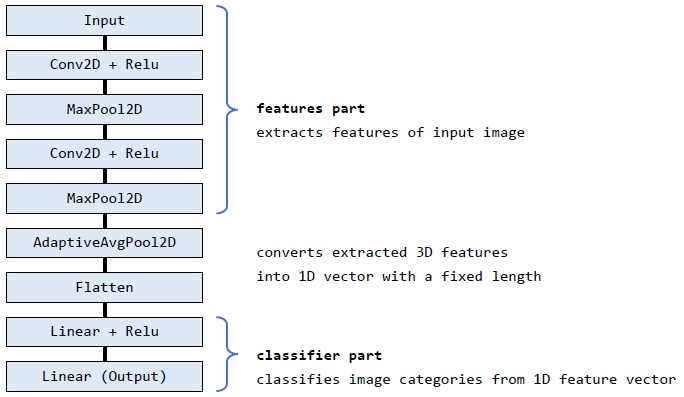

In [11]:
import torch.nn as nn

# make our own class named "Model"
class Model(nn.Module):

    # Constructor: this runs when we make a model
    def __init__(self):                 # do not change
        super(Model, self).__init__()   # do not change

        # "features": find the patterns in the image
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        # "junction": make a fixed size, then change it into 1D data
        self.junction = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=(8, 8)),
            nn.Flatten()
        )

        # "classifier": decide the group from the features
        self.classifier = nn.Sequential(
            nn.Linear(in_features=64*8*8, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=10)
        )

    # forward(): this runs when we give data to the model
    def forward(self, x):   # do not change
        x = self.features(x)
        x = self.junction(x)
        x = self.classifier(x)
        return x

model = Model()    # make a model
print(model)

Model(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (junction): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(8, 8))
    (1): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)


Next, we send the model to the GPU.

In [12]:
model = model.to(device)

Let's look at the model with the `torchinfo` package. It shows how the shape of the data changes in each layer, so it is very useful for understanding a model.

In [13]:
! pip install torchinfo
from torchinfo import summary

for x_batch, _ in train_loader:
    break

input_shape = x_batch.shape
print("\ninput data shape:", input_shape)

summary(model, input_shape)


input data shape: torch.Size([50, 3, 32, 32])


Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [50, 10]                  --
├─Sequential: 1-1                        [50, 64, 8, 8]            --
│    └─Conv2d: 2-1                       [50, 64, 32, 32]          1,792
│    └─ReLU: 2-2                         [50, 64, 32, 32]          --
│    └─MaxPool2d: 2-3                    [50, 64, 16, 16]          --
│    └─Conv2d: 2-4                       [50, 64, 16, 16]          36,928
│    └─ReLU: 2-5                         [50, 64, 16, 16]          --
│    └─MaxPool2d: 2-6                    [50, 64, 8, 8]            --
├─Sequential: 1-2                        [50, 4096]                --
│    └─AdaptiveAvgPool2d: 2-7            [50, 64, 8, 8]            --
│    └─Flatten: 2-8                      [50, 4096]                --
├─Sequential: 1-3                        [50, 10]                  --
│    └─Linear: 2-9                       [50, 256]                 1,048,832
│

### Conv2D Layer

A `nn.Conv2D` layer uses small **filters** (also called kernels). A filter is smaller than the image, and it moves over the whole image. At each position, we multiply the numbers of the filter and the numbers of the image, and add them up. This calculation is called **convolution**, and the result is the output image.

One Conv2D layer usually has many different filters, and each filter makes one output channel. Each filter finds a different pattern, for example a vertical edge or a horizontal edge.

The numbers inside the filters are **trainable parameters**. The model does not know good filters at the start; it learns them during training.

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

#### Example-1

`nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=0)`
*   The input is a gray image of (1x6x6), so `in_channels=1`
*   We use only one filter of (1x3x3), so `out_channels=1` and `kernel_size=3`
*   We add nothing around the image, so `padding=0`



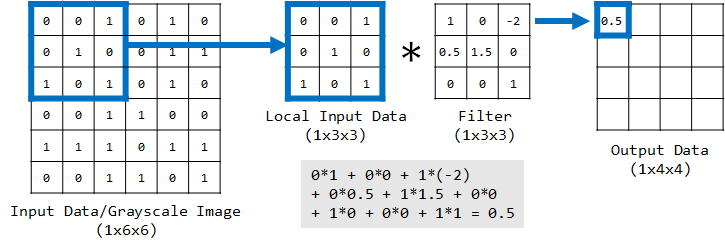

#### Example-2

`nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=0)`
*   The input is a color image of (3x6x6), so `in_channels=3`
*   We use only one filter of (3x3x3), so `out_channels=1` and `kernel_size=3`
*   We add nothing around the image, so `padding=0`


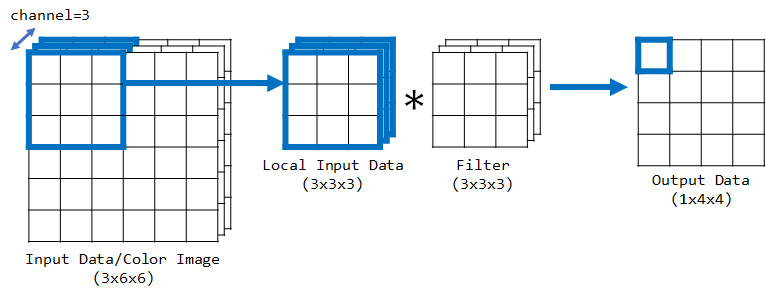

#### Example-3
`nn.Conv2d(in_channels=3, out_channels=5, kernel_size=3, padding=0)`
*   The input is a color image of (3x6x6), so `in_channels=3`
*   We use 5 filters of (3x3x3), so `out_channels=5` and `kernel_size=3`
*   We add nothing around the image, so `padding=0`

Please note that the output has 5 channels, because we used 5 filters.

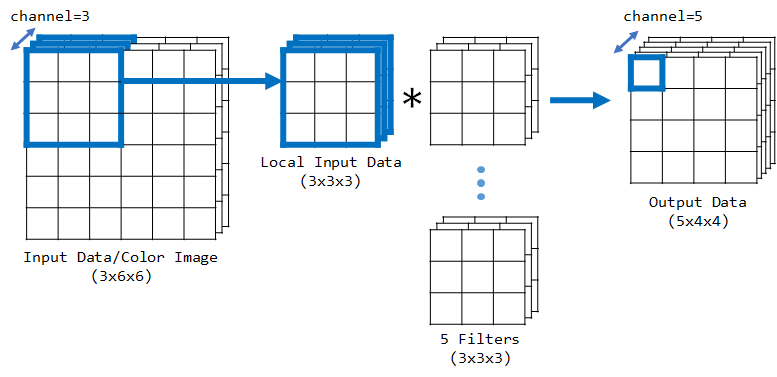

#### Example-4
`nn.Conv2d(in_channels=5, out_channels=10, kernel_size=3, padding=1)`
*   The input is the output of Example-3 (5x4x4), so `in_channels=5`
*   We use 10 filters of (5x3x3), so `out_channels=10` and `kernel_size=3`
*   We add a border of 0 around all 4 sides, so `padding=1`

**Padding** means we put extra 0s around the image. Without padding, the output becomes smaller than the input. With `padding=1` and `kernel_size=3`, the output keeps the same height and width as the input.

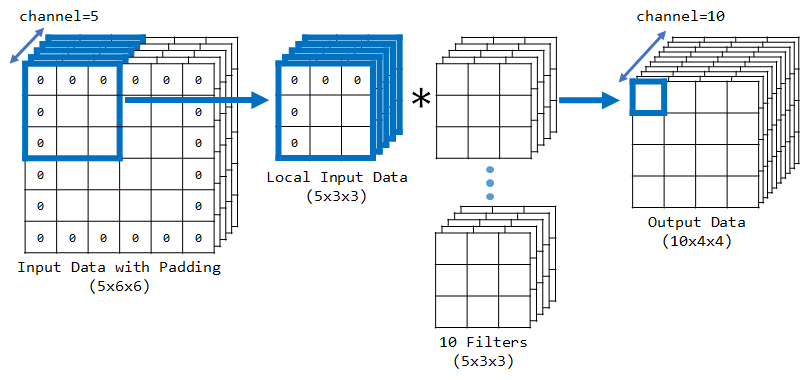

Let's try the code below and see how a Conv2D layer works. You can change the numbers in the input image and in the filter, and run it again.

Text(0.5, 1.0, 'Output (Convoluted)')

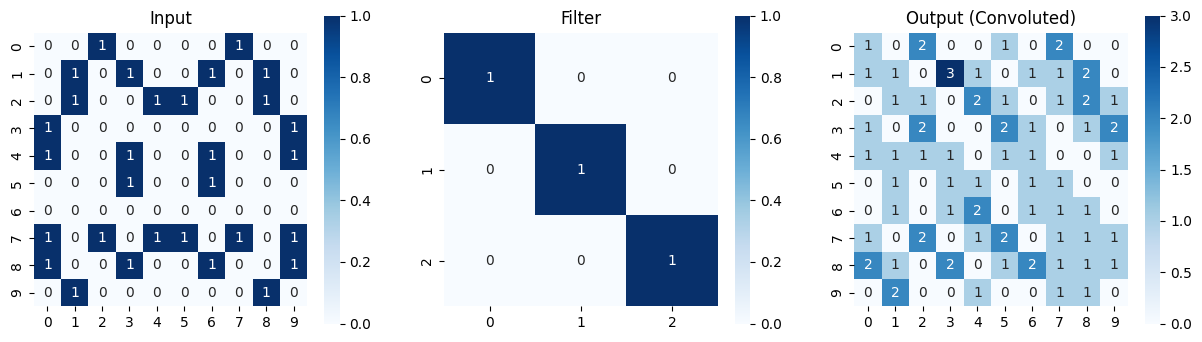

In [14]:
# input image (10x10) --- do not change
input_img = torch.tensor([0,0,1,0,0,0,0,1,0,0,
                          0,1,0,1,0,0,1,0,1,0,
                          0,1,0,0,1,1,0,0,1,0,
                          1,0,0,0,0,0,0,0,0,1,
                          1,0,0,1,0,0,1,0,0,1,
                          0,0,0,1,0,0,1,0,0,0,
                          0,0,0,0,0,0,0,0,0,0,
                          1,0,1,0,1,1,0,1,0,1,
                          1,0,0,1,0,0,1,0,0,1,
                          0,1,0,0,0,0,0,0,1,0], dtype=torch.float32)
input_img = input_img.view(1, 1, 10, 10)

# define a Conv2d layer
conv = nn.Conv2d(in_channels=1,
                 out_channels=1,
                 kernel_size=3,
                 padding=1,
                 bias=False)

# set the numbers inside the filter by hand
weights = (torch.tensor([[1, 0, 0],
                         [0, 1, 0],
                         [0, 0, 1]]).view(1, 1, 3, 3).float()
                         )
conv.weight = nn.Parameter(weights)

# do the convolution
conv_img = conv(input_img)

# draw the input image, the filter and the output image
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(torch.squeeze(input_img).numpy(), annot=True, square=True, cmap="Blues")
plt.title(f"Input")

plt.subplot(1,3,2)
sns.heatmap(torch.squeeze(weights).numpy(), annot=True, square=True, cmap="Blues")
plt.title(f"Filter")

plt.subplot(1,3,3)
sns.heatmap(torch.squeeze(conv_img).detach().numpy(), annot=True, square=True, cmap="Blues")
plt.title(f"Output (Convoluted)")

### MaxPool2D Layer

A `nn.MaxPool2D` layer makes the image smaller. It looks at a small area of the input (here 2x2) and keeps only the **largest** value in that area. This is called **max pooling**.

Why do we make the image smaller? Because it makes the next calculations lighter, and because the exact position of a pattern is not so important. We only need to know that the pattern is somewhere around there.

https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html

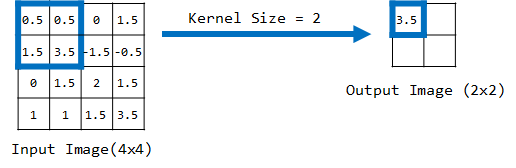

Text(0.5, 1.0, 'Output (Max Pooled)')

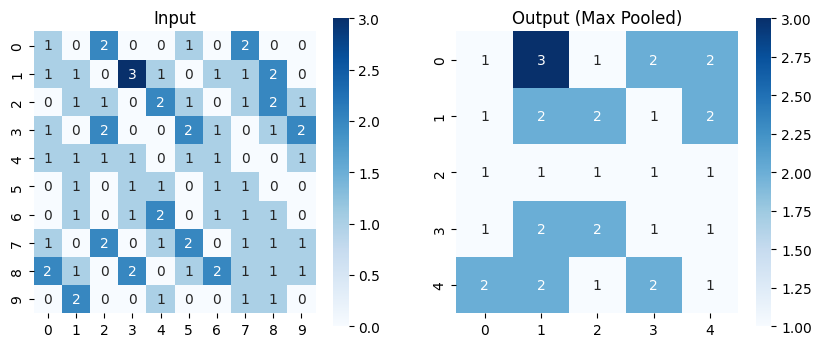

In [15]:
# define a MaxPool2d layer
max_pool = nn.MaxPool2d(kernel_size=2, stride=None, padding=0)

# do the max pooling
pool_img = max_pool(conv_img)

# draw the input and the output
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(torch.squeeze(conv_img).detach().numpy(), annot=True, square=True, cmap="Blues")
plt.title("Input")

plt.subplot(1,2,2)
sns.heatmap(torch.squeeze(pool_img).detach().numpy(), annot=True, square=True, cmap="Blues")
plt.title("Output (Max Pooled)")

### AdaptiveAvgPool2D

A `nn.AdaptiveAvgPool2d` layer also makes the image smaller, but it takes the **average** of each area, not the largest value. The useful point of this layer is that we choose the **output** size, so the output is always the same size. Because of this, the `Linear` layer after it always gets the same number of values.

https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html

Text(0.5, 1.0, 'Output(Adaptive Avg Pooled)')

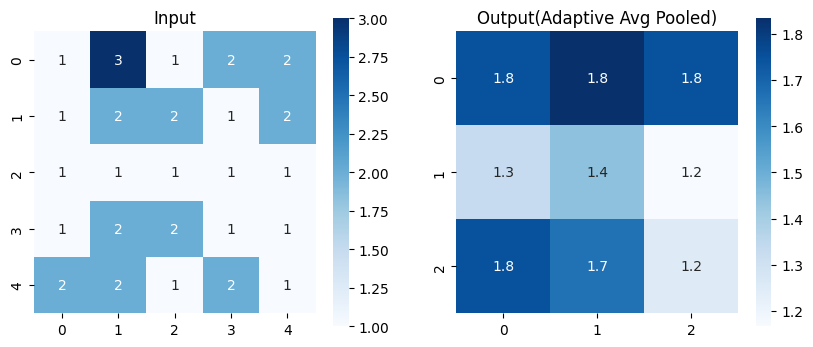

In [16]:
# define an AdaptiveAvgPool2d layer
aap = nn.AdaptiveAvgPool2d(output_size=(3, 3))

# do the average pooling
avg_img = aap(pool_img)

# draw the input and the output
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(torch.squeeze(pool_img).detach().numpy(), annot=True, square=True, cmap="Blues")
plt.title("Input")

plt.subplot(1,2,2)
sns.heatmap(torch.squeeze(avg_img).detach().numpy(), annot=True, square=True, cmap="Blues")
plt.title("Output(Adaptive Avg Pooled)")

### Flatten

A `nn.Flatten` layer changes multi-dimensional data into 1D data. We need this because a `Linear` layer can only take 1D data. The numbers do not change; only their shape changes.

https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html

Text(0.5, 1.0, 'Output (Flattened)')

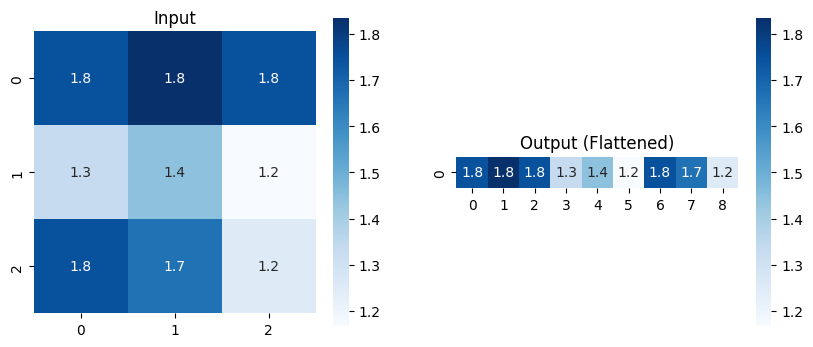

In [17]:
flatten = nn.Flatten()
flatten_data = flatten(avg_img)

# draw the input and the output
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(torch.squeeze(avg_img).detach().numpy(), annot=True, square=True, cmap="Blues")
plt.title("Input")

plt.subplot(1,2,2)
sns.heatmap(flatten_data.detach().numpy(), annot=True, square=True, cmap="Blues")
plt.title("Output (Flattened)")

## Training

### Loss Function

This is a classification task, so we use the cross-entropy loss.

In [18]:
loss_func = nn.CrossEntropyLoss()

### Optimizer

We use the Adam optimizer.

In [19]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1E-3)

### Training Loop
Now let's train the model with the CIFAR10 dataset. The training loop is almost the same as last week. The one new point is that we send both the data and the model to the GPU.

The dataset is large, so one epoch takes some time. `tqdm` shows a progress bar, so we can see how much is finished.





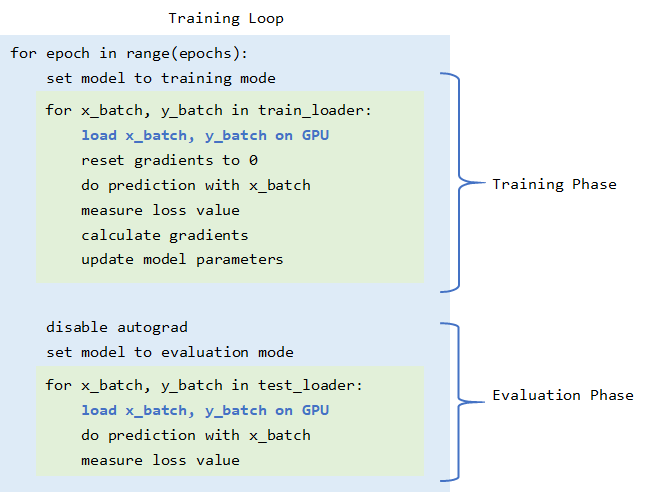

In [20]:
model = Model().to(device)                             # make a new model and send it to the GPU
loss_func = nn.CrossEntropyLoss()                      # set loss function
optimizer = optim.Adam(model.parameters(), lr=1E-3)    # set optimizer

epochs = 10

# empty lists for saving the results of each epoch
train_loss_list = []
train_accuracy_list = []
test_loss_list = []
test_accuracy_list = []

for epoch in range(epochs):
    print("-----------------------------")
    print(f"Epoch {epoch+1}/{epochs}")

    # reset the numbers for this epoch
    train_correct_count = 0
    train_accuracy = 0
    train_loss = 0
    test_correct_count = 0
    test_accuracy = 0
    test_loss = 0

    #--- Training Phase ---#
    model.train()    # set model to training mode

    for x_batch, y_batch in tqdm(train_loader): # take one mini-batch from train_loader

        x_batch = x_batch.to(device)     # send x_batch to the GPU
        y_batch = y_batch.to(device)     # send y_batch to the GPU

        optimizer.zero_grad()                  # reset the gradients to 0
        p_batch = model(x_batch)               # make a prediction
        loss = loss_func(p_batch, y_batch)     # measure loss
        loss.backward()                        # calculate the gradients
        optimizer.step()                       # update model parameters

        train_loss += loss.item()                                # add up the loss
        p_batch_label = torch.argmax(p_batch, dim=1)             # the largest output = the predicted label
        train_correct_count += (p_batch_label == y_batch).sum()  # count the correct predictions
    #----------------------#

    #--- Evaluation Phase ---#
    with torch.no_grad():   # no gradients here, so it uses less memory
        model.eval()        # set model to evaluation mode

        for x_batch, y_batch in tqdm(test_loader):   # take one mini-batch from test_loader

            x_batch = x_batch.to(device)     # send x_batch to the GPU
            y_batch = y_batch.to(device)     # send y_batch to the GPU

            p_batch = model(x_batch)              # make a prediction
            loss = loss_func(p_batch, y_batch)    # measure loss

            test_loss += loss.item()                                # add up the loss
            p_batch_label = torch.argmax(p_batch, dim=1)            # the largest output = the predicted label
            test_correct_count += (p_batch_label == y_batch).sum()  # count the correct predictions
    #------------------------#

    train_accuracy = train_correct_count/len(train_dataset)   # accuracy for the training data
    test_accuracy = test_correct_count/len(test_dataset)      # accuracy for the test data
    train_loss = train_loss/len(train_loader)                 # average loss for the training data
    test_loss = test_loss/len(test_loader)                    # average loss for the test data

    # print and save the results
    print(f"Train: Accuracy={train_accuracy:.3f} Loss={train_loss:.3f}, Test: Accuracy={test_accuracy:.3f} Loss={test_loss:.3f}")
    train_accuracy_list.append(train_accuracy.item())
    train_loss_list.append(train_loss)
    test_accuracy_list.append(test_accuracy.item())
    test_loss_list.append(test_loss)

-----------------------------
Epoch 1/10


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Train: Accuracy=0.487 Loss=1.425, Test: Accuracy=0.595 Loss=1.142
-----------------------------
Epoch 2/10


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

Train: Accuracy=0.876 Loss=0.350, Test: Accuracy=0.697 Loss=1.036
-----------------------------
Epoch 10/10


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Train: Accuracy=0.902 Loss=0.282, Test: Accuracy=0.706 Loss=1.098


### Learning Curves

Let's draw the accuracy curves for the training data and the test data.

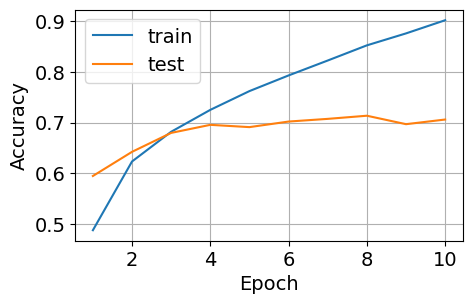

In [21]:
plt.figure(figsize=(5,3))
plt.rcParams["font.size"]=14
plt.plot(np.arange(epochs)+1, train_accuracy_list, label="train")
plt.plot(np.arange(epochs)+1, test_accuracy_list, label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

Let's also draw the loss curves for the training data and the test data.

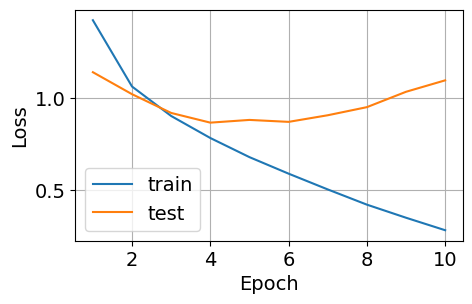

In [22]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(epochs)+1, train_loss_list, label="train")
plt.plot(np.arange(epochs)+1, test_loss_list, label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()

### Overfit

Please look at the curves again. The training accuracy keeps going up, but the test accuracy stops going up after a few epochs. The training loss keeps going down, but the test loss stops going down and then starts going **up**.

This means the model is learning the training data too much. It can answer the training data very well, but it is weak with new data that it has never seen. This problem is called **overfitting**.

It is like a student who memorizes the answers of old exams. The student gets a perfect score on those old exams, but cannot answer new questions.

Deep neural networks have very many trainable parameters, so they overfit easily. They can simply memorize the training data instead of learning general patterns.

There are several ways to stop overfitting, and we will learn them next week.

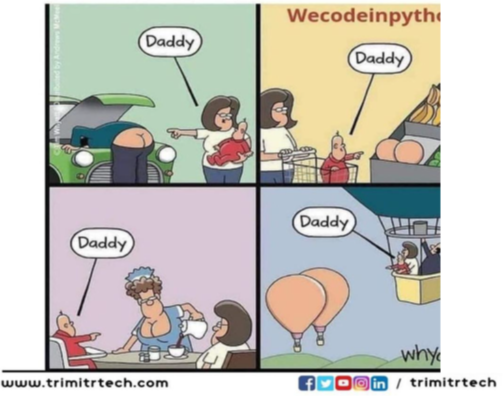

## Evaluation

### Test Accuracy

Let's check the accuracy of the trained model with all the test data.

In [23]:
test_accuracy = 0

y_test_all = np.array([])
p_label_all = np.array([])

with torch.no_grad():    # no gradients here
    model.eval()         # set model to evaluation mode

    for x_batch, y_batch in test_loader:    # take one mini-batch from test_loader
        x_batch = x_batch.to(device)        # send x_batch to the GPU
        y_batch = y_batch.to(device)        # send y_batch to the GPU
        p_batch = model(x_batch)            # make a prediction

        p_batch_label = torch.argmax(p_batch, dim=1)       # the largest output = the predicted label
        test_accuracy += (p_batch_label == y_batch).sum()  # count the correct predictions

        y_test_all = np.append(y_test_all, y_batch.to("cpu").numpy())          # save the correct answers
        p_label_all = np.append(p_label_all, p_batch_label.to("cpu").numpy())  # save the predictions

test_accuracy = test_accuracy/len(test_dataset)      # accuracy for the test data
print(f"Test Accuracy = {test_accuracy:.3f}")

Test Accuracy = 0.706


### Confusion Matrix

Let's also look at the confusion matrix. It shows the accuracy for each group, so we can see which groups the model mixes up (for example, cats and dogs).

Text(0.5, 1.0, 'confusion matrix')

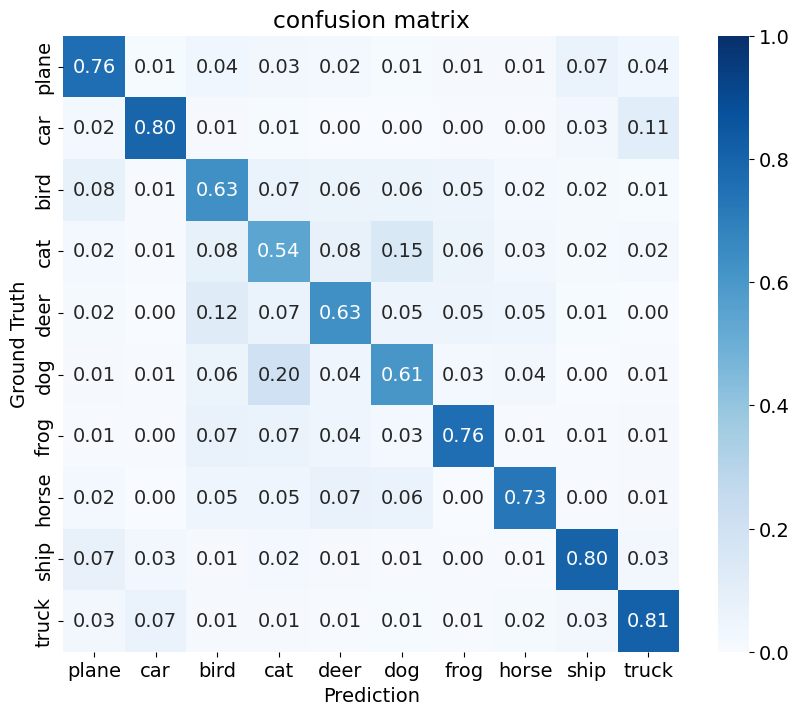

In [24]:
from sklearn.metrics import confusion_matrix

cmx = confusion_matrix(y_test_all, p_label_all)

cmx_pct = np.zeros(cmx.shape)

for i in range(cmx.shape[0]):
    for j in range(cmx.shape[1]):
        cmx_pct[i, j] = cmx[i, j]/cmx[i, :].sum()

plt.figure(figsize=(10,8))
labels = classnames.values()

sns.heatmap(cmx_pct, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=classnames.values(), yticklabels=classnames.values(), square=True)

plt.ylabel("Ground Truth")
plt.xlabel("Prediction")
plt.title("confusion matrix")

### Predictions for Test Data

Let's look at the predictions for some test images. "T" is the true label and "P" is the prediction. A green title means the prediction is correct, and a red title means it is wrong.

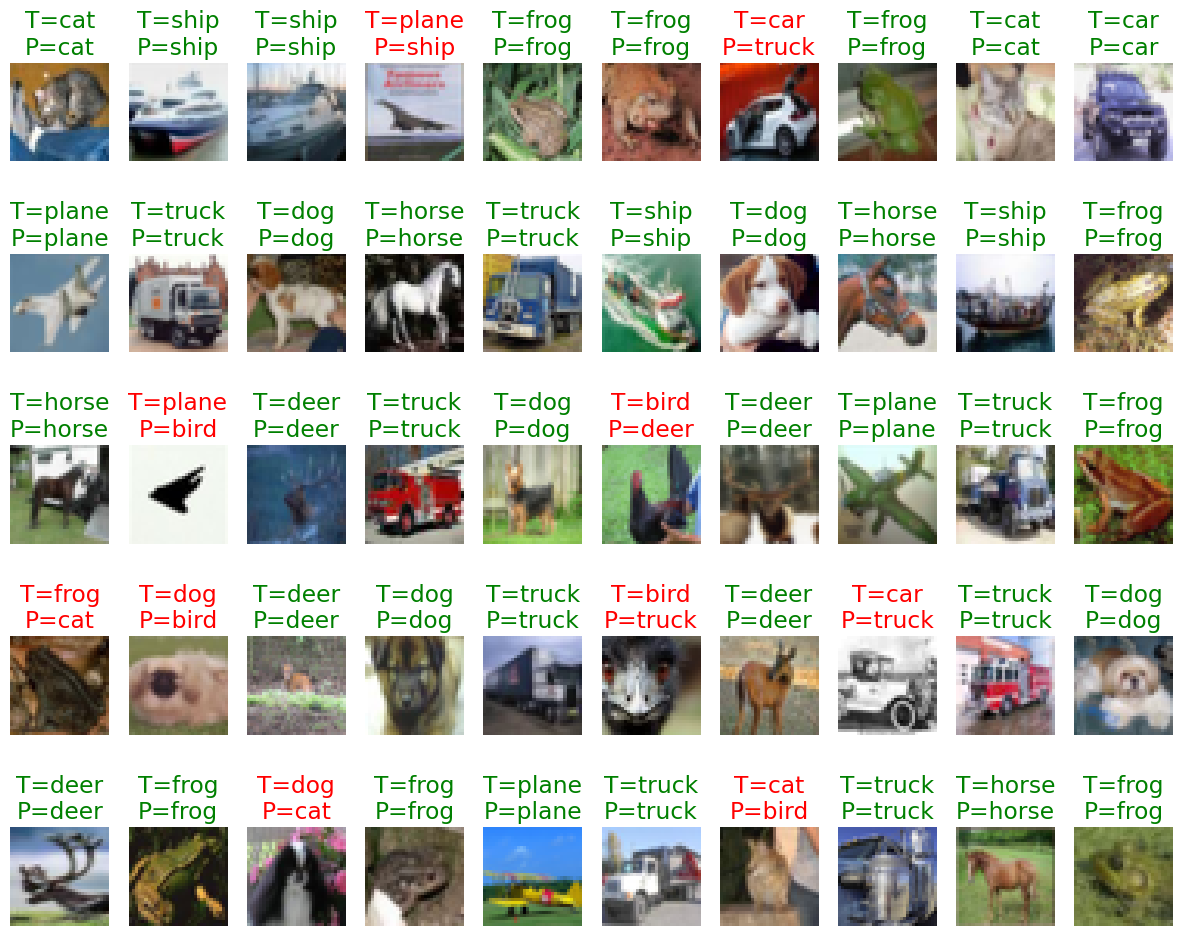

In [25]:
plt.figure(figsize=(15, 12))

for i in range(50):
    image, _ = test_dataset[i]
    image = np.transpose(image, (1,2,0))
    plt.subplot(5, 10, i+1)
    plt.imshow(image)

    true_class = classnames[y_test_all[i]]
    pred_class = classnames[p_label_all[i]]
    if true_class == pred_class:
        color = "green"
    else:
        color = "red"
    plt.title(f"T={true_class}\nP={pred_class}", color=color)
    plt.axis("off")


## Practice

Change the model as shown below, and train it again.

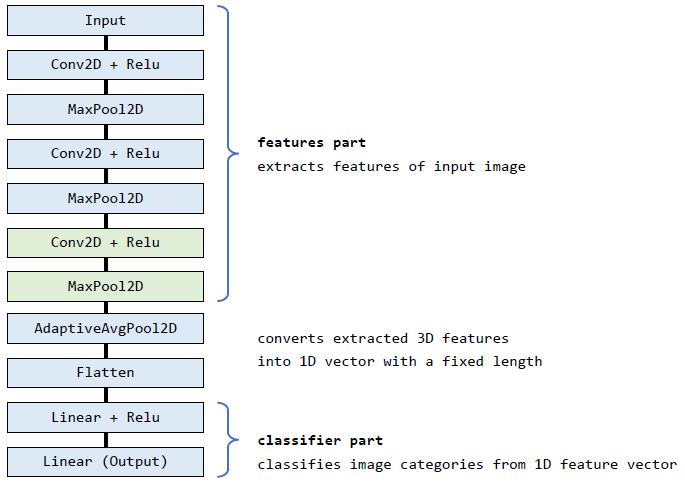

## Conclusion
That's it for this week. Now you can try to get a better test accuracy by changing the hyperparameters, for example the number of filters, the number of layers, the batch size, the learning rate and the number of epochs.